# Band Evaluation - Can the Pipeline Work with Images not NIR?
### PolyU Cross-Sensor Iris Evaluation

This notebook evaluates the performance of the **open-iris** pipeline on the PolyU Cross-Sensor Iris Dataset across three modalities:
- **NIR** — near-infrared images (grayscale)
- **VIS** — visible-light images (converted to grayscale)
- **VIS_R** — visible-light images, red channel only

The goal is to measure how well the system can recognize individuals across:
- Different sessions (Session 1 vs. Session 2)
- Different imaging modalities (NIR, VIS, VIS_R)

Cross-session and cross-sensor matching is significantly more challenging than same-session matching due to lighting differences, sensor variability, and natural biological variation. This evaluation helps assess how robust the system is under realistic conditions.

 
**Metrics:** 
- EER (Equal Error Rate) - where false acceptance rate (FAR) is equal to false rejection rate (FRR)
- AUC (Area Under Curve) - overall separability of genuine vs. imposter scores
- TAR@FAR - system usability at strict security thresholds
- Hamming Distance - similarity between iris templates

## Imports

This section loads all required libraries for image processing, iris feature extraction, matching and evaluation, and visualization of results. These libraries support the full biometric pipeline from raw image input to performance metrics. 

In [1]:
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import tifffile
import iris
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import defaultdict
from itertools import combinations

print(f"open-iris version: {iris.__version__}")

open-iris version: 1.11.0


## Configuration

Edit these values to match your setup. This file uses the *Hong Kong Polytechnic University Cross-Spectral Iris Images Database* which can be accessed [here](https://www4.comp.polyu.edu.hk/~csajaykr/polyuiris.htm).

In [2]:
# Path to the PolyU_Cross_Submit folder
DATA_ROOT = Path("../PolyU_Cross_Submit")

# Number of subjects to use for cross-session matching 
# (max 16, since Session 2 only has 001–016)
N_SUBJECTS = 16

# Random seed for reproducibility
SEED = 42
rng = random.Random(SEED)
np.random.seed(SEED)

# ── Fixed constants ───────────────────────────────────────
MODALITIES = ["NIR", "VIS", "VIS_R"]
EYE_SIDES  = ["L", "R"]
SESSION_1_ROOT = "PolyU_Cross_Session_1/PolyU_Cross_Iris"
SESSION_2_ROOT = "PolyU_Cross_Session_2/PolyU_Cross_Iris_Session_2"

## Helper functions

In [3]:
def load_tiff_as_gray(path: Path, modality: str) -> Optional[np.ndarray]:
# Load a TIFF and return a uint8 grayscale array
    # NIR   : already grayscale, returned as-is
    # VIS   : RGB → grayscale via standard luminance weights
    # VIS_R : red channel (index 0 in RGB) extracted as grayscale   
    try:
        img = tifffile.imread(str(path))
    except Exception as exc:
        warnings.warn(f"Could not read {path}: {exc}")
        return None

    if img.dtype != np.uint8:
        img = (img / img.max() * 255).astype(np.uint8) if img.max() > 0 else img.astype(np.uint8)

    if img.ndim == 2:
        return img
    elif img.ndim == 3:
        if modality == "VIS_R":
            return img[:, :, 0]
        else:
            return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        warnings.warn(f"Unexpected shape {img.shape} in {path}")
        return None


def gather_images(subject_id: str, eye_side: str, modality: str,) -> Dict[str, List[Path]]:
# Return {"s1": [paths], "s2": [paths]} for one subject/eye/modality.
    folder_mod = "VIS" if modality == "VIS_R" else modality
    s1_dir = DATA_ROOT / SESSION_1_ROOT / subject_id / eye_side / folder_mod
    s2_dir = DATA_ROOT / SESSION_2_ROOT / subject_id / eye_side / folder_mod

    def _find(d: Path) -> List[Path]:
        if not d.exists():
            return []
        return sorted(d.glob("*.tif")) + sorted(d.glob("*.tiff"))

    return {"s1": _find(s1_dir), "s2": _find(s2_dir)}


def encode_image(pipeline: iris.IRISPipeline, path: Path, modality: str, eye_side: str, image_id: str,):
# Run the IRIS pipeline on one image; return IrisTemplate or None
    gray = load_tiff_as_gray(path, modality)
    if gray is None:
        return None
    iris_side = "left" if eye_side == "L" else "right"
    try:
        output = pipeline(iris.IRImage(img_data=gray, image_id=image_id, eye_side=iris_side))
        return output.get("iris_template", None)
    except Exception as exc:
        warnings.warn(f"Pipeline failed on {path}: {exc}")
        return None


def compute_metrics(genuine_scores: List[float], impostor_scores: List[float],) -> Dict[str, float]:
# Compute EER, AUC, TAR@FAR=0.01 and 0.001 from Hamming distance lists
    labels = [1] * len(genuine_scores) + [0] * len(impostor_scores)
    scores = [1 - d for d in genuine_scores + impostor_scores]

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)

    fnr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2)

    def tar_at_far(target_far: float) -> float:
        idx = max(0, np.searchsorted(fpr, target_far, side="right") - 1)
        return float(tpr[idx])

    return {
        "EER":             eer,
        "AUC":             auc,
        "TAR@FAR=0.01":    tar_at_far(0.01),
        "TAR@FAR=0.001":   tar_at_far(0.001),
        "Mean_Genuine_HD": float(np.mean(genuine_scores)),
        "Mean_Impostor_HD":float(np.mean(impostor_scores)),
        "N_Genuine":       len(genuine_scores),
        "N_Impostor":      len(impostor_scores),
    }

## Select subjects

Session 1 has subjects 001-209 and Session 2 has subjects 001-016. In this segment, we are doing cross-section matching (Session 1 vs. Session 2). The code filters subjects to those that exist in both sessions. Again, subjects are limited to those present in Session 2 (001–016) so genuine cross-session pairs exist.

In [4]:
s2_dir = DATA_ROOT / SESSION_2_ROOT
available_subjects = sorted(
    d.name for d in s2_dir.iterdir() if d.is_dir() and d.name.isdigit()
)

n = min(N_SUBJECTS, len(available_subjects))
subject_ids = rng.sample(available_subjects, n)

print(f"Available subjects in Session 2 : {len(available_subjects)}")
print(f"Using {n} subjects: {subject_ids}")

Available subjects in Session 2 : 11
Using 11 subjects: ['016', '002', '001', '008', '015', '011', '010', '013', '003', '005', '012']


## Initialize pipeline and matcher

Here, the `IRISPipeline` and `HammingDistanceMatcher` are initialized. 
- `IRISPipeline` handles iris segmentation, normalization, and feature encoding as well as converts raw images into biometric templates
- `HammingDistanceMatcher` compares two iris templates and outputs a similarity score (Hamming Distance)

Essentially, the pipeline extracts meaningful features and the matcher determines whether two samples belong to the same person.

In [5]:
pipeline = iris.IRISPipeline()
matcher  = iris.HammingDistanceMatcher()
print("Pipeline and matcher ready.")

iris_semseg_upp_scse_mobilenetv2.onnx:   0%|          | 0.00/56.1M [00:00<?, ?B/s]

Pipeline and matcher ready.


## Encode images and compute scores

For each modality (NIR, VIS, VIS_R):

1. Images are passed through the pipeline to generate iris templates
2. Templates are compared to computing Hamming Distance
3. Scores are grouped into:
   - **Genuine pairs** — (same person)
   - **Impostor pairs** — (different people)

A lower Hamming Distance means the iris templates are more similar and thus likely of the same person. On the other hand, higher Hamming Distances indicate less similarity and the images are likely of different people.

**Important Note:** In this segment, the dataset is *highly imbalanced*. It may bias evaluation metrics and are fixed later on in the file.

In [9]:
all_results: Dict[str, Dict] = {}

for modality in MODALITIES:
    print(f"\n{'='*55}")
    print(f"  Modality: {modality}")
    print(f"{'='*55}")

    # ── Encode all images ────────────────────────────────────────────────────
    # templates[subj][eye_side] = {"s1": [...], "s2": [...]}
    templates: Dict[str, Dict[str, Dict[str, list]]] = {}

    for subj in tqdm(subject_ids, desc=f"  Encoding [{modality}]"):
        templates[subj] = {}
        for eye_side in EYE_SIDES:
            img_map = gather_images(subj, eye_side, modality)
            s1_temps = [
                t for p in img_map["s1"]
                if (t := encode_image(pipeline, p, modality, eye_side,
                                      f"{subj}_{eye_side}_s1_{p.stem}")) is not None
            ]
            s2_temps = [
                t for p in img_map["s2"]
                if (t := encode_image(pipeline, p, modality, eye_side,
                                      f"{subj}_{eye_side}_s2_{p.stem}")) is not None
            ]
            if s1_temps and s2_temps:
                templates[subj][eye_side] = {"s1": s1_temps, "s2": s2_temps}

    # ── Genuine scores ───────────────────────────────────────────────────────
    genuine_scores: List[float] = []
    for subj, sides in templates.items():
        for eye_side, sessions in sides.items():
            for t1 in sessions["s1"]:
                for t2 in sessions["s2"]:
                    try:
                        genuine_scores.append(float(matcher.run(t1, t2)))
                    except Exception:
                        pass

    # ── Impostor scores ──────────────────────────────────────────────────────
    impostor_scores: List[float] = []
    side_pools: Dict[str, List[Tuple[str, object]]] = {s: [] for s in EYE_SIDES}
    for subj, sides in templates.items():
        for eye_side, sessions in sides.items():
            if sessions["s1"]:
                side_pools[eye_side].append((subj, sessions["s1"][0]))

    for eye_side, pool in side_pools.items():
        if len(pool) < 2:
            continue
        subjs = [p[0] for p in pool]
        temps_ = [p[1] for p in pool]
        indices = list(range(len(pool)))
        n_imp = min(len(genuine_scores) * 2, len(pool) * (len(pool) - 1) // 2)
        sampled: set = set()
        attempts = 0
        while len(impostor_scores) < n_imp and attempts < n_imp * 10:
            attempts += 1
            i, j = rng.sample(indices, 2)
            if subjs[i] == subjs[j]:
                continue
            key = (min(i, j), max(i, j))
            if key in sampled:
                continue
            sampled.add(key)
            try:
                impostor_scores.append(float(matcher.run(temps_[i], temps_[j])))
            except Exception:
                pass

    print(f"  Genuine pairs : {len(genuine_scores)}")
    print(f"  Impostor pairs: {len(impostor_scores)}")

    if genuine_scores and impostor_scores:
        metrics = compute_metrics(genuine_scores, impostor_scores)
        all_results[modality] = {
            **metrics,
            "genuine_scores":  genuine_scores,
            "impostor_scores": impostor_scores,
        }
        for k, v in metrics.items():
            print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")
    else:
        print("  ⚠ Not enough scores to compute metrics.")
        all_results[modality] = {}


  Modality: NIR


  Encoding [NIR]:   0%|          | 0/11 [00:00<?, ?it/s]

  Genuine pairs : 4650
  Impostor pairs: 55
  EER                   : 0.4173
  AUC                   : 0.6365
  TAR@FAR=0.01          : 0.3419
  TAR@FAR=0.001         : 0.3419
  Mean_Genuine_HD       : 0.3603
  Mean_Impostor_HD      : 0.4422
  N_Genuine             : 4650
  N_Impostor            : 55

  Modality: VIS


  Encoding [VIS]:   0%|          | 0/11 [00:00<?, ?it/s]

  Genuine pairs : 1174
  Impostor pairs: 28
  EER                   : 0.3179
  AUC                   : 0.7126
  TAR@FAR=0.01          : 0.2726
  TAR@FAR=0.001         : 0.2726
  Mean_Genuine_HD       : 0.4205
  Mean_Impostor_HD      : 0.4588
  N_Genuine             : 1174
  N_Impostor            : 28

  Modality: VIS_R


  Encoding [VIS_R]:   0%|          | 0/11 [00:00<?, ?it/s]

  Genuine pairs : 881
  Impostor pairs: 28
  EER                   : 0.2504
  AUC                   : 0.8106
  TAR@FAR=0.01          : 0.4200
  TAR@FAR=0.001         : 0.4200
  Mean_Genuine_HD       : 0.3964
  Mean_Impostor_HD      : 0.4536
  N_Genuine             : 881
  N_Impostor            : 28



As a reminder on metrics,
- **EER (Equal Error Rate)** is the point where false acceptances and false rejections are equal. Lower is better.
- **AUC (Area Under Curve)** measures how well the system separates genuine vs. imposter scores. Closer to 1.0 is better.
- **TAR@FAR=0.01** is the true acceptance rate when the false acceptance is limited to 1%. It reflects performance in security-sensisitve settings. Similarly, **TAR@FAR=0.001** is the true acceptance rate when the false acceptance is limited to 0.1%.
- **Mean Hamming Distance** genuine should be low and the imposter should be high.

If the genuine and imposter scores overlap significantly then the system will make more errors.

## Summary table

The evaluation being performed here is essentially `intersection(Session1, Session2)`. When comparing modalities:
- Lower EER implies better performance
- Higher AUC implies better separation
- Higher TAR implies a more usable system


In [12]:
METRIC_KEYS = ["EER", "AUC", "TAR@FAR=0.01", "TAR@FAR=0.001",
               "Mean_Genuine_HD", "Mean_Impostor_HD", "N_Genuine", "N_Impostor"]

rows = {}
for mod in MODALITIES:
    rows[mod] = {k: all_results.get(mod, {}).get(k, float("nan")) for k in METRIC_KEYS}

df = pd.DataFrame(rows, index=METRIC_KEYS).T
df.index.name = "Modality"
df

,EER,AUC,TAR@FAR=0.01,TAR@FAR=0.001,Mean_Genuine_HD,Mean_Impostor_HD,N_Genuine,N_Impostor
Modality,,,,,,,,
NIR,0.417263,0.636465,0.341935,0.341935,0.360347,0.442190,4650.0,55.0
VIS,0.317869,0.712582,0.272572,0.272572,0.420461,0.458840,1174.0,28.0
VIS_R,0.250426,0.810605,0.419977,0.419977,0.396365,0.453588,881.0,28.0


## Score distribution plots

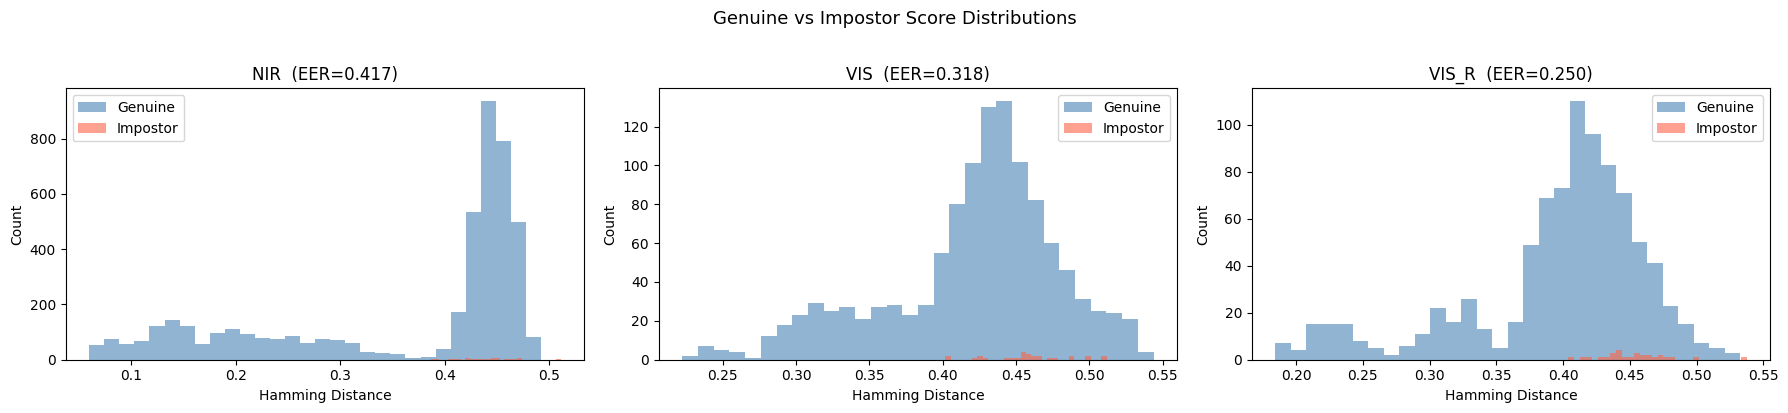

In [13]:
fig, axes = plt.subplots(1, len(MODALITIES), figsize=(6 * len(MODALITIES), 4), sharey=False)

for ax, mod in zip(axes, MODALITIES):
    res = all_results.get(mod, {})
    if not res:
        ax.set_title(f"{mod} — no data")
        continue
    ax.hist(res["genuine_scores"],  bins=30, alpha=0.6, color="steelblue", label="Genuine")
    ax.hist(res["impostor_scores"], bins=30, alpha=0.6, color="tomato",    label="Impostor")
    ax.set_title(f"{mod}  (EER={res['EER']:.3f})")
    ax.set_xlabel("Hamming Distance")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Genuine vs Impostor Score Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## ROC curves

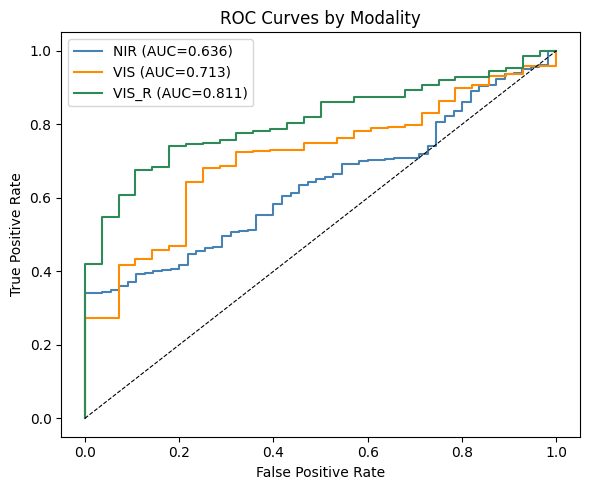

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"NIR": "steelblue", "VIS": "darkorange", "VIS_R": "seagreen"}

for mod in MODALITIES:
    res = all_results.get(mod, {})
    if not res:
        continue
    labels = [1] * len(res["genuine_scores"]) + [0] * len(res["impostor_scores"])
    scores = [1 - d for d in res["genuine_scores"] + res["impostor_scores"]]
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    ax.plot(fpr, tpr, label=f"{mod} (AUC={res['AUC']:.3f})", color=colors[mod])

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves by Modality")
ax.legend()
plt.tight_layout()
plt.show()

---

## Balanced Dataset Selection

Earlier results used an imbalanced dataset where the number of genuine pairs heavily outweighed the number of imposter pairs which can result in overly optimistic performance and biased metrics.

Here, we rebalance the dataset by generating additional imposter pairs and matching the number of imposter pairs to genuine pairs. This provides a fairer evaluation of system performance and better reflects real-world behavior.

In [18]:
# Target number of impostors per modality (adjust as needed)
N_IMPOSTOR_TARGET = 1000

all_results: dict = {}

for modality in MODALITIES:
    print("\n" + "="*60)
    print(f"  Modality: {modality}")
    print("="*60)

    templates: dict = {}
    for subj in tqdm(subject_ids, desc=f"Encoding [{modality}]"):
        templates[subj] = {}
        for eye_side in EYE_SIDES:
            img_map = gather_images(subj, eye_side, modality)
            s1_temps = [
                t for p in img_map["s1"]
                if (t := encode_image(pipeline, p, modality, eye_side,
                                      f"{subj}_{eye_side}_s1_{p.stem}")) is not None
            ]
            s2_temps = [
                t for p in img_map["s2"]
                if (t := encode_image(pipeline, p, modality, eye_side,
                                      f"{subj}_{eye_side}_s2_{p.stem}")) is not None
            ]
            if s1_temps and s2_temps:
                templates[subj][eye_side] = {"s1": s1_temps, "s2": s2_temps}

    genuine_scores = []
    for subj, sides in templates.items():
        for eye_side, sessions in sides.items():
            for t1 in sessions["s1"]:
                for t2 in sessions["s2"]:
                    try:
                        genuine_scores.append(float(matcher.run(t1, t2)))
                    except Exception:
                        pass
    print(f"Genuine pairs (raw)   : {len(genuine_scores)}")

    impostor_pool = defaultdict(list)
    for subj, sides in templates.items():
        for eye_side, sessions in sides.items():
            for sess_name in ["s1", "s2"]:
                for t in sessions[sess_name]:
                    impostor_pool[eye_side].append((subj, t))

    def generate_impostors(pool, target_n):
        scores = []
        seen = set()
        eye_keys = list(pool.keys())

        attempts = 0
        max_attempts = target_n * 10

        while len(scores) < target_n and attempts < max_attempts:
            attempts += 1
            eye = random.choice(eye_keys)
            entries = pool[eye]

            if len(entries) < 2:
                continue

            i, j = random.sample(range(len(entries)), 2)
            subj_i, t1 = entries[i]
            subj_j, t2 = entries[j]

            if subj_i == subj_j:
                continue

            key = tuple(sorted((id(t1), id(t2))))
            if key in seen:
                continue
            seen.add(key)

            try:
                scores.append(float(matcher.run(t1, t2)))
            except Exception:
                continue

        return scores

    print("Generating impostor pairs...")
    impostor_scores = generate_impostors(impostor_pool, N_IMPOSTOR_TARGET)
    print(f"Impostor pairs (raw)  : {len(impostor_scores)}")

    min_n = min(len(genuine_scores), len(impostor_scores))
    genuine_bal = random.sample(genuine_scores, min_n)
    impostor_bal = random.sample(impostor_scores, min_n)

    print(f"Balanced pairs        : Genuine={len(genuine_bal)}, Impostor={len(impostor_bal)}")

    metrics = compute_metrics(genuine_bal, impostor_bal)

    all_results[modality] = {
        **metrics,
        "genuine_scores": genuine_bal,
        "impostor_scores": impostor_bal,
    }

    print("\nMetrics:")
    for k, v in metrics.items():
        print(f"{k:<25}: {v:.4f}" if isinstance(v, float) else f"{k:<25}: {v}")


  Modality: NIR


Encoding [NIR]: 100%|███████████████████████████| 11/11 [13:26<00:00, 73.31s/it]


Genuine pairs (raw)   : 4650
Generating impostor pairs...
Impostor pairs (raw)  : 1000
Balanced pairs        : Genuine=1000, Impostor=1000

Metrics:
EER                      : 0.3840
AUC                      : 0.6734
TAR@FAR=0.01             : 0.3160
TAR@FAR=0.001            : 0.0040
Mean_Genuine_HD          : 0.3622
Mean_Impostor_HD         : 0.4441
N_Genuine                : 1000
N_Impostor               : 1000

  Modality: VIS


Encoding [VIS]: 100%|███████████████████████████| 11/11 [13:10<00:00, 71.87s/it]


Genuine pairs (raw)   : 1174
Generating impostor pairs...
Impostor pairs (raw)  : 1000
Balanced pairs        : Genuine=1000, Impostor=1000

Metrics:
EER                      : 0.3820
AUC                      : 0.6522
TAR@FAR=0.01             : 0.1980
TAR@FAR=0.001            : 0.0000
Mean_Genuine_HD          : 0.4205
Mean_Impostor_HD         : 0.4504
N_Genuine                : 1000
N_Impostor               : 1000

  Modality: VIS_R


Encoding [VIS_R]: 100%|█████████████████████████| 11/11 [13:22<00:00, 72.96s/it]


Genuine pairs (raw)   : 881
Generating impostor pairs...
Impostor pairs (raw)  : 1000
Balanced pairs        : Genuine=881, Impostor=881

Metrics:
EER                      : 0.3331
AUC                      : 0.7216
TAR@FAR=0.01             : 0.1941
TAR@FAR=0.001            : 0.1873
Mean_Genuine_HD          : 0.3964
Mean_Impostor_HD         : 0.4403
N_Genuine                : 881
N_Impostor               : 881


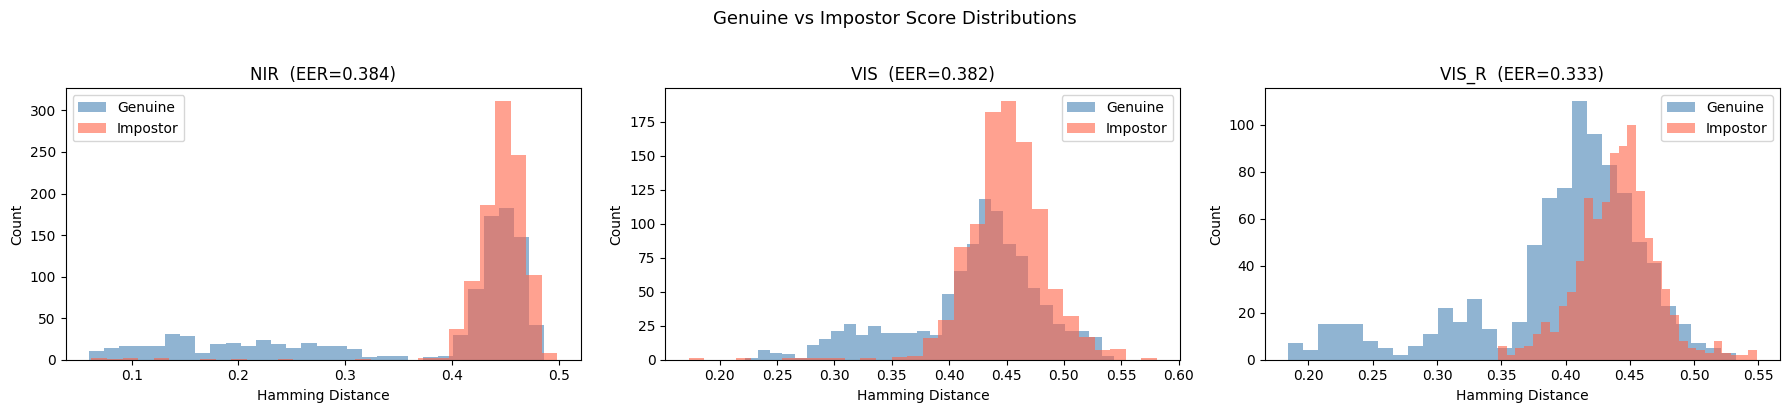

In [19]:
fig, axes = plt.subplots(1, len(MODALITIES), figsize=(6 * len(MODALITIES), 4), sharey=False)

for ax, mod in zip(axes, MODALITIES):
    res = all_results.get(mod, {})
    if not res:
        ax.set_title(f"{mod} — no data")
        continue
    ax.hist(res["genuine_scores"],  bins=30, alpha=0.6, color="steelblue", label="Genuine")
    ax.hist(res["impostor_scores"], bins=30, alpha=0.6, color="tomato",    label="Impostor")
    ax.set_title(f"{mod}  (EER={res['EER']:.3f})")
    ax.set_xlabel("Hamming Distance")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Genuine vs Impostor Score Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

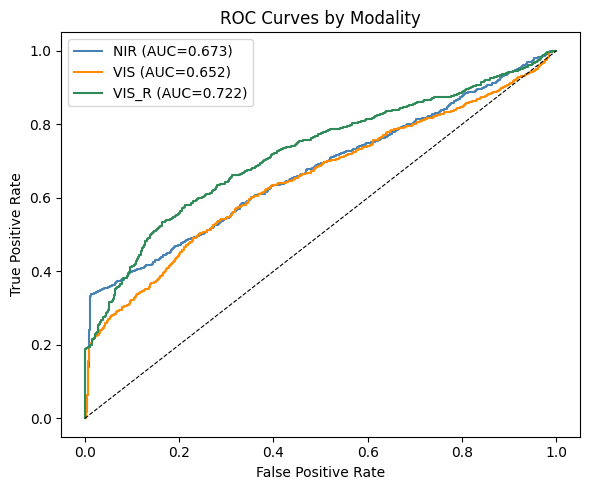

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"NIR": "steelblue", "VIS": "darkorange", "VIS_R": "seagreen"}

for mod in MODALITIES:
    res = all_results.get(mod, {})
    if not res:
        continue
    labels = [1] * len(res["genuine_scores"]) + [0] * len(res["impostor_scores"])
    scores = [1 - d for d in res["genuine_scores"] + res["impostor_scores"]]
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    ax.plot(fpr, tpr, label=f"{mod} (AUC={res['AUC']:.3f})", color=colors[mod])

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves by Modality")
ax.legend()
plt.tight_layout()
plt.show()

---

## Session 1 Only

To start, the gather_images file is updated to only focus on session one.

In [6]:
N_SUBJECTS        = 20
N_IMPOSTOR_TARGET = 3000

def gather_images_s1(subject_id: str, eye_side: str, modality: str) -> List[Path]:
    folder_mod = "VIS" if modality == "VIS_R" else modality
    s1_dir = DATA_ROOT / SESSION_1_ROOT / subject_id / eye_side / folder_mod

    if not s1_dir.exists():
        return []

    return sorted(s1_dir.glob("*.tif")) + sorted(s1_dir.glob("*.tiff"))

s1_dir = DATA_ROOT / SESSION_1_ROOT
available_subjects = sorted(d.name for d in s1_dir.iterdir() if d.is_dir() and d.name.isdigit())
n = min(N_SUBJECTS, len(available_subjects))

rng = random.Random(42)
subject_ids = rng.sample(available_subjects, n)

print(f"Available subjects in Session 1 : {len(available_subjects)}")

Available subjects in Session 1 : 209


Then the encoding loop is updated for the 209 subjects from the first session.

In [9]:
all_results: Dict[str, Dict] = {}

for modality in MODALITIES:
    print(f"\n{'='*55}")
    print(f"  Modality: {modality}")
    print(f"{'='*55}")

    templates: Dict[str, Dict[str, List]] = {}

    for subj in tqdm(subject_ids, desc=f"  Encoding [{modality}]"):
        templates[subj] = {}

        for eye_side in EYE_SIDES:
            paths = gather_images_s1(subj, eye_side, modality)

            temps = [
                t for p in paths
                if (t := encode_image(
                    pipeline, p, modality, eye_side,
                    f"{subj}_{eye_side}_s1_{p.stem}"
                )) is not None
            ]

            if len(temps) >= 2:
                templates[subj][eye_side] = temps

    genuine_scores: List[float] = []

    for subj, sides in templates.items():
        for eye_side, temps in sides.items():
            for t1, t2 in combinations(temps, 2):
                try:
                    genuine_scores.append(float(matcher.run(t1, t2)))
                except Exception:
                    pass

    print(f"  Genuine pairs (raw) : {len(genuine_scores)}")

    impostor_pool = defaultdict(list)

    for subj, sides in templates.items():
        for eye_side, temps in sides.items():
            for t in temps:
                impostor_pool[eye_side].append((subj, t))

    def generate_impostors(pool, target_n):
        scores = []
        seen = set()
        eye_keys = list(pool.keys())

        attempts = 0
        max_attempts = target_n * 10

        while len(scores) < target_n and attempts < max_attempts:
            attempts += 1

            eye = random.choice(eye_keys)
            entries = pool[eye]

            if len(entries) < 2:
                continue

            i, j = random.sample(range(len(entries)), 2)
            subj_i, t1 = entries[i]
            subj_j, t2 = entries[j]

            if subj_i == subj_j:
                continue

            key = tuple(sorted((id(t1), id(t2))))
            if key in seen:
                continue
            seen.add(key)

            try:
                scores.append(float(matcher.run(t1, t2)))
            except Exception:
                continue

        return scores

    print("  Generating impostor pairs...")
    impostor_scores = generate_impostors(impostor_pool, N_IMPOSTOR_TARGET)

    print(f"  Impostor pairs (raw): {len(impostor_scores)}")

    if genuine_scores and impostor_scores:
        n_bal = min(len(genuine_scores), len(impostor_scores))

        genuine_bal = random.sample(genuine_scores, n_bal)
        impostor_bal = random.sample(impostor_scores, n_bal)

        print(f"  → Balanced pairs    : {n_bal} vs {n_bal}")

        metrics = compute_metrics(genuine_bal, impostor_bal)

        all_results[modality] = {
            **metrics,
            "genuine_scores": genuine_bal,
            "impostor_scores": impostor_bal,
        }

        for k, v in metrics.items():
            print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

    else:
        print("Not enough scores to compute metrics.")
        all_results[modality] = {}


  Modality: NIR


  Encoding [NIR]:   0%|          | 0/20 [00:00<?, ?it/s]

  Genuine pairs (raw) : 3270
  Generating impostor pairs...
  Impostor pairs (raw): 3000
  → Balanced pairs    : 3000 vs 3000
  EER                   : 0.0183
  AUC                   : 0.9971
  TAR@FAR=0.01          : 0.9847
  TAR@FAR=0.001         : 0.9823
  Mean_Genuine_HD       : 0.0881
  Mean_Impostor_HD      : 0.4416
  N_Genuine             : 3000
  N_Impostor            : 3000

  Modality: VIS


  Encoding [VIS]:   0%|          | 0/20 [00:00<?, ?it/s]

  Genuine pairs (raw) : 775
  Generating impostor pairs...
  Impostor pairs (raw): 3000
  → Balanced pairs    : 775 vs 775
  EER                   : 0.0974
  AUC                   : 0.9665
  TAR@FAR=0.01          : 0.8284
  TAR@FAR=0.001         : 0.7768
  Mean_Genuine_HD       : 0.2500
  Mean_Impostor_HD      : 0.4548
  N_Genuine             : 775
  N_Impostor            : 775

  Modality: VIS_R


  Encoding [VIS_R]:   0%|          | 0/20 [00:00<?, ?it/s]

  Genuine pairs (raw) : 671
  Generating impostor pairs...
  Impostor pairs (raw): 3000
  → Balanced pairs    : 671 vs 671
  EER                   : 0.0447
  AUC                   : 0.9939
  TAR@FAR=0.01          : 0.9225
  TAR@FAR=0.001         : 0.8912
  Mean_Genuine_HD       : 0.2104
  Mean_Impostor_HD      : 0.4400
  N_Genuine             : 671
  N_Impostor            : 671


,EER,AUC,TAR@FAR=0.01,TAR@FAR=0.001,Mean_Genuine_HD,Mean_Impostor_HD,N_Genuine,N_Impostor
Modality,,,,,,,,
NIR,0.018333,0.997103,0.984667,0.982333,0.088075,0.441624,3000.0,3000.0
VIS,0.097419,0.966455,0.828387,0.776774,0.250037,0.454845,775.0,775.0
VIS_R,0.044709,0.993921,0.922504,0.891207,0.210397,0.440029,671.0,671.0


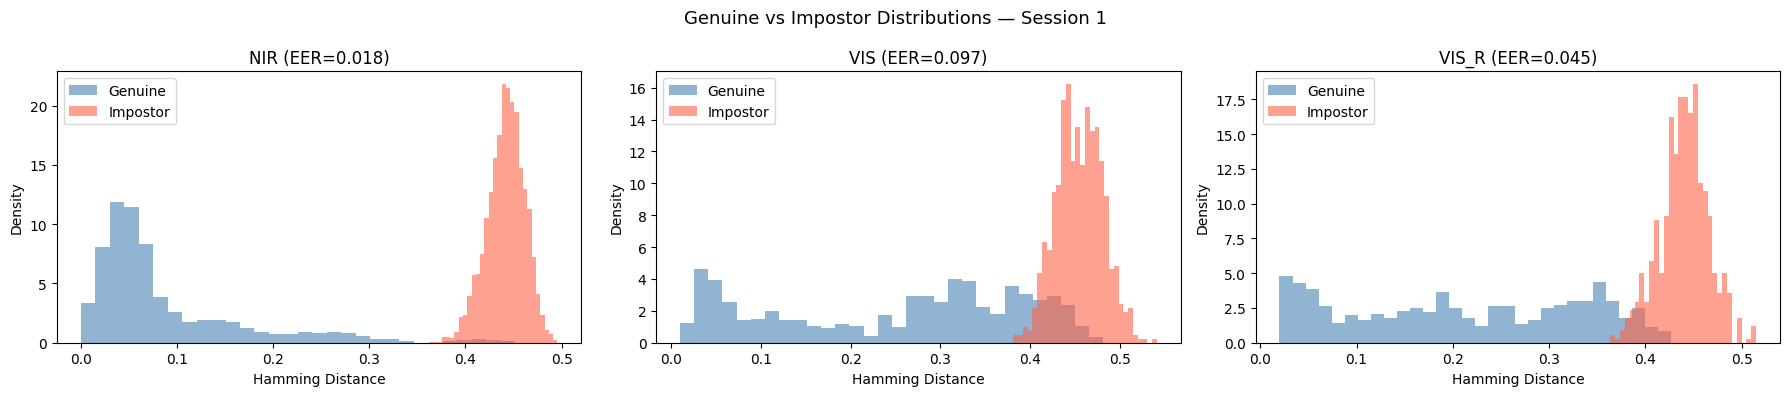

In [14]:
METRIC_KEYS = []
for mod in MODALITIES:
    res = all_results.get(mod, {})
    if res:
        METRIC_KEYS = [k for k, v in res.items() if isinstance(v, (int, float))]
        break

df = pd.DataFrame(
    {
        mod: {k: all_results.get(mod, {}).get(k, np.nan) for k in METRIC_KEYS}
        for mod in MODALITIES
    }
).T

df.index.name = "Modality"
display(df)

fig, axes = plt.subplots(1, len(MODALITIES), figsize=(6 * len(MODALITIES), 4))

for ax, mod in zip(axes, MODALITIES):
    res = all_results.get(mod, {})

    if not res or "genuine_scores" not in res:
        ax.set_title(f"{mod} — no data")
        ax.axis("off")
        continue

    ax.hist(
        res["genuine_scores"],
        bins=30,
        alpha=0.6,
        color="steelblue",
        label="Genuine",
        density=True
    )

    ax.hist(
        res["impostor_scores"],
        bins=30,
        alpha=0.6,
        color="tomato",
        label="Impostor",
        density=True
    )

    eer = res.get("EER", np.nan)

    ax.set_title(f"{mod} (EER={eer:.3f})")
    ax.set_xlabel("Hamming Distance")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Genuine vs Impostor Distributions — Session 1", fontsize=13)
plt.tight_layout()
plt.show()

---

## Final Metric Comparison Table

**Cross-Session Comparisons**

| Attempt|EER | AUC | TAR@FAR=0.01 | TAR@FAR=0.001 | Genuine HD | Imposter HD| Genuine Pairs | Imposter Pairs|
|--|--|--|--|--|--|--|--|--|
|Unbalanced NIR| 0.4173 | 0.6365 | 0.3419 | 0.3419 | 0.3603 | 0.4422 | 4650 | 55 |
|Balanced NIR| 0.3840 | 0.6734 | 0.3160 | 0.0040 | 0.3622 | 0.4441 | 1000 | 1000 |
|Unbalanced VIS| 0.3179 | 0.7126 | 0.2726 | 0.2726 | 0.4205 | 0.4588 | 1174 | 28 |
|Balanced VIS| 0.3820 | 0.6522 | 0.1980 | 0.0000 | 0.4205 | 0.4504 | 1000 | 1000 |
|Unbalanced VIS_R| 0.2504 | 0.8106 | 0.4200 | 0.4200 | 0.3964 | 0.4536 | 881 | 28 |
|Balanced VIS_R| 0.3331 | 0.7216 | 0.1941 | 0.1873 | 0.3964 | 0.4403 | 881 | 881 |


**Session One Comparisons**

| Attempt|EER | AUC | TAR@FAR=0.01 | TAR@FAR=0.001 | Genuine HD | Imposter HD| Genuine Pairs | Imposter Pairs|
|--|--|--|--|--|--|--|--|--|
|Unbalanced NIR| 0.0186 | 0.9968 | 0.9835 | 0.9829 | 0.0879 | 0.4401 | 3270 | 190 |
| Balanced NIR| 0.0183 | 0.9971 | 0.9847 | 0.9823 | 0.0881 | 0.4416 | 3000 | 3000 |
|Unbalanced VIS| 0.1476 | 0.9360 | 0.7961 | 0.7961 | 0.2500 | 0.4388 | 775 | 55 |
| Balanced VIS| 0.0974 | 0.9665 | 0.8284 | 0.7768 | 0.2500 | 0.4548 | 775 | 775 |
|Unbalanced VIS_R| 0.0428 | 0.9929 | 0.9121 | 0.9121 | 0.2104 | 0.4395 | 671 | 66 |
|Balanced VIS_R| 0.0447 | 0.9939 | 0.9225 | 0.8912 | 0.2104 | 0.4400 | 671 | 671 |
